# 0. Import Libraries

In [78]:
import numpy as np
from dataclasses import dataclass
import time
import matplotlib.pyplot as plt

# 1. System Configuration


## Parameters

In [79]:
@dataclass
class SystemConfig:
    sample_rate: float = 1e6      # 取樣率 1 MHz
    symbol_rate: float = 1e5      # 符元率 100 kBaud
    snr_db: float = 30.0          # 訊雜比 (目前 B2B 測試暫不生效)
    payload_text: str = "Hello Satellite! This is a test message from Earth."

## Visualization

In [80]:
class SignalVisualizer:
    """提供通訊系統除錯與分析的靜態繪圖方法"""

    @staticmethod
    def plot_constellation(symbols: np.ndarray, title: str = "QPSK Constellation Diagram"):
        """繪製複數符元的星座圖"""
        # 建立畫布
        plt.figure(figsize=(6, 6))

        # 將複數陣列分離為 I (實部) 與 Q (虛部)
        i_coords = np.real(symbols)
        q_coords = np.imag(symbols)

        # 繪製接收到的訊號點 (Scatter plot)
        plt.scatter(i_coords, q_coords, c='blue', alpha=0.5, s=10, label='Received Symbols')

        # 繪製視覺輔助線：理想的單位圓 (能量為 1)
        circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', alpha=0.5, label='Unit Power Circle')
        plt.gca().add_patch(circle)

        # 繪製十字座標軸 (Decision Boundaries)
        plt.axhline(0, color='black', linewidth=1, alpha=0.5)
        plt.axvline(0, color='black', linewidth=1, alpha=0.5)

        # 圖表格式設定
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel("In-Phase (I)", fontsize=12)
        plt.ylabel("Quadrature (Q)", fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.axis('equal')  # 關鍵：確保 I 和 Q 軸比例一致，圓形才不會變橢圓
        plt.xlim(-1.5, 1.5)
        plt.ylim(-1.5, 1.5)
        plt.legend(loc='upper right')

        # 顯示圖表
        plt.tight_layout()
        plt.show()

## Usage

In [81]:
class RRCPulseShaper:
    def __init__(self, sps=4, span=11, alpha=0.35):
        """
        sps (Samples per symbol): 每個符元的取樣點數 (升取樣倍率)
        span: 濾波器的跨距 (涵蓋幾個符元長度)
        alpha: 滾降係數 (Roll-off factor)，決定頻寬超出極限的比例
        """
        self.sps = sps
        self.span = span
        self.alpha = alpha
        self.taps = self._generate_rrc_taps()

    def _generate_rrc_taps(self) -> np.ndarray:
        """產生 RRC 濾波器的係數 (Taps)"""
        # 計算總濾波器長度
        taps_len = self.span * self.sps + 1
        # 建立以 0 為中心的時間陣列
        t = np.arange(taps_len) - (taps_len - 1) / 2

        # 加入微小的偏移量以避免公式中出現「除以零」的奇異點
        t = t + 1e-8

        # RRC 數學公式實作
        Ts = self.sps # 正規化符元週期
        pi = np.pi
        alpha = self.alpha

        num = np.sin(pi * t * (1 - alpha) / Ts) + \
              4 * alpha * t / Ts * np.cos(pi * t * (1 + alpha) / Ts)
        den = pi * t / Ts * (1 - (4 * alpha * t / Ts)**2)

        h = num / den
        # 能量正規化，確保濾波器增益正確
        return h / np.sqrt(np.sum(h**2))

    def process(self, symbols: np.ndarray) -> np.ndarray:
        """對輸入符元進行升取樣與濾波"""
        # 1. 升取樣 (Upsampling)：在符元間補零
        upsampled = np.zeros(len(symbols) * self.sps, dtype=np.complex64)
        upsampled[::self.sps] = symbols

        # 2. 卷積 (Convolution)：讓脈衝通過 RRC 濾波器
        # mode='same' 確保輸出長度與輸入相同 (延遲在後續接收端會處理)
        shaped_signal = np.convolve(upsampled, self.taps, mode='same')

        return shaped_signal

class MatchedFilter:
    def __init__(self, sps=4, span=11, alpha=0.35):
        """參數必須與發射端的 RRCPulseShaper 完全一致"""
        self.sps = sps
        self.span = span
        self.alpha = alpha
        self.taps = self._generate_rrc_taps()

    def _generate_rrc_taps(self) -> np.ndarray:
        """與 TX 端完全相同的 RRC 係數生成邏輯"""
        taps_len = self.span * self.sps + 1
        t = np.arange(taps_len) - (taps_len - 1) / 2 + 1e-8
        Ts = self.sps
        pi = np.pi
        alpha = self.alpha

        num = np.sin(pi * t * (1 - alpha) / Ts) + \
              4 * alpha * t / Ts * np.cos(pi * t * (1 + alpha) / Ts)
        den = pi * t / Ts * (1 - (4 * alpha * t / Ts)**2)
        h = num / den

        return h / np.sqrt(np.sum(h**2))

    def process(self, rx_waveform: np.ndarray) -> np.ndarray:
        """
        將接收到的含雜訊波形通過匹配濾波器。
        這會濾除頻寬外的雜訊，並在時域上將訊號的能量匯聚到最高點 (峰值)。
        """
        return np.convolve(rx_waveform, self.taps, mode='same')

# 2. System Modules


## Module Transmitter

### QPSK Modulator

In [82]:
class QPSKModulator:
    def __init__(self):
        # 定義 QPSK 星座圖 (使用 Gray Code)
        # 位元對應: '00' ->  1 + 1j
        #         '01' -> -1 + 1j
        #         '11' -> -1 - 1j
        #         '10' ->  1 - 1j
        # 乘以 1/sqrt(2) 進行能量正規化
        self.normalization_factor = 1.0 / np.sqrt(2.0)
        self.mapping_table = {
            (0, 0): complex(1, 1)   * self.normalization_factor,
            (0, 1): complex(-1, 1)  * self.normalization_factor,
            (1, 1): complex(-1, -1) * self.normalization_factor,
            (1, 0): complex(1, -1)  * self.normalization_factor
        }

    def process(self, bits: np.ndarray) -> np.ndarray:
        """將 1D 位元陣列轉換為 1D 複數符元陣列"""
        # 確保位元數量是偶數，若不是則補 0
        if len(bits) % 2 != 0:
            bits = np.append(bits, 0)

        # 將位元兩兩分組
        bit_pairs = bits.reshape(-1, 2)

        # 使用 list comprehension 與 mapping table 快速轉換 (向量化替代方案亦可)
        symbols = [self.mapping_table[tuple(pair)] for pair in bit_pairs]
        return np.array(symbols, dtype=np.complex64)

### Transmitter

In [83]:
class Transmitter:
    def __init__(self, config):
        self.config = config
        self.modulator = QPSKModulator()
        # 新增脈衝整形器，從 config 讀取 sps 參數 (假設為 4)
        self.pulse_shaper = RRCPulseShaper(sps=int(config.sample_rate / config.symbol_rate))

    def process(self, text_data: str) -> np.ndarray:
        # 1. Source Coding: 字串轉位元
        bits_str = ''.join(format(ord(char), '08b') for char in text_data)
        bits = np.array([int(b) for b in bits_str], dtype=np.int8)

        # 2. Modulation: 數位調變 -> QPSK 複數符元
        baseband_symbols = self.modulator.process(bits)

        # 3. Pulse Shaping: 升取樣與脈衝整形 (新增此步驟！)
        tx_waveform = self.pulse_shaper.process(baseband_symbols)

        return tx_waveform

## Module Channel

In [84]:
class Channel:
    def __init__(self, config):
        self.config = config

    def process(self, tx_signal: np.ndarray) -> np.ndarray:
        """
        模擬真實物理通道：加入基礎的 AWGN (加性高斯白雜訊)
        這會讓星座圖上的點產生散射，模擬真實衛星接收到的訊號狀態。
        """
        # 設定一個隨機的雜訊能量 (目前為硬編碼，僅供視覺化測試)
        noise_variance = 0.05
        #noise_variance = 0

        # 產生複數高斯雜訊 (I 軸與 Q 軸都要有雜訊)
        noise = np.random.normal(0, np.sqrt(noise_variance/2), len(tx_signal)) + \
                1j * np.random.normal(0, np.sqrt(noise_variance/2), len(tx_signal))

        # 將雜訊疊加到發射訊號上
        rx_signal = tx_signal + noise
        return rx_signal

## Module Receiver

### QPSK Demodulator

In [85]:
class QPSKDemodulator:
    def __init__(self):
        # 對應的解調邏輯：透過判斷 I 和 Q 的正負號來還原位元
        pass

    def process(self, symbols: np.ndarray) -> np.ndarray:
        """將複數符元還原為位元陣列 (Hard Decision)"""
        bits = np.zeros(len(symbols) * 2, dtype=np.int8)

        # 判斷 I (實部)
        # I > 0 代表 bit 0 是 0 (對應 1-1j 或 1+1j)
        # I < 0 代表 bit 0 是 1 (對應 -1+1j 或 -1-1j)
        bits[0::2] = (np.real(symbols) < 0).astype(np.int8)

        # 判斷 Q (虛部)
        # 根據我們的 mapping:
        # 實部 > 0 時，虛部 > 0 -> (0,0), 虛部 < 0 -> (1,0)  [這裡需特別處理 Gray code 的反向映射]
        # 更簡單且強健的硬體判決寫法如下：

        # I 通道判決
        bits[0::2] = np.where(np.real(symbols) > 0, 0, 1)
        # Q 通道判決 (觀察 Mapping: I=1,Q=1->00; I=-1,Q=1->01. 發現只要 Q>0，第二個 bit 就是 0 嗎？不是。)
        # 讓我們直接用距離最小化 (Minimum Distance) 來做，這樣最不容易出錯，且適用於任何星座圖。

        # 重建 mapping table keys 與 values
        mapping_keys = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
        norm = 1.0 / np.sqrt(2.0)
        mapping_vals = np.array([1+1j, -1+1j, -1-1j, 1-1j]) * norm

        demodulated_bits = []
        for sym in symbols:
            # 計算接收符元與 4 個理想星座點的歐幾里得距離
            distances = np.abs(sym - mapping_vals)
            # 找出距離最近的索引
            min_index = np.argmin(distances)
            demodulated_bits.extend(mapping_keys[min_index])

        return np.array(demodulated_bits, dtype=np.int8)

### Receiver

In [86]:
class Receiver:
    def __init__(self, config):
        self.config = config
        self.sps = int(config.sample_rate / config.symbol_rate)
        self.matched_filter = MatchedFilter(sps=self.sps)
        self.demodulator = QPSKDemodulator()

    def process(self, rx_waveform: np.ndarray) -> str:
        # Step 1: 匹配濾波 (Matched Filtering) -> 將 SNR 最大化
        filtered_signal = self.matched_filter.process(rx_waveform)

        # Step 2: 降取樣 (Downsampling) -> 抽取出能量峰值的符元
        rx_symbols = filtered_signal[::self.sps]

        # === 【修正】在這裡繪製，才是真正的接收端星座點！ ===
        SignalVisualizer.plot_constellation(rx_symbols, "Downsampled RX Symbols")

        # Step 3: 數位解調 (Demodulation)
        bits = self.demodulator.process(rx_symbols)

        # Step 4: 位元轉字串 (Source Decoding)
        chars = []
        valid_length = (len(bits) // 8) * 8
        for i in range(0, valid_length, 8):
            byte_val = int("".join(str(b) for b in bits[i:i+8]), 2)
            chars.append(chr(byte_val))

        return "".join(chars)

# 3. Testbench Runner


In [87]:
class EndToEndTestbench:
    def __init__(self, config):
        self.config = config
        self.tx = Transmitter(config)
        self.channel = Channel(config)
        self.rx = Receiver(config)

    def run_b2b_test(self):
        print(f"--- 啟動 Back-to-Back 系統測試 ---")

        test_payload = SystemConfig.payload_text
        print(f"[Input] 傳送字元數: {len(test_payload)} chars")

        start_time = time.time()

        # 1. 發射端處理 (字串 -> 位元 -> QPSK 複數符元)
        tx_symbols = self.tx.process(test_payload)

        # 2. 衛星通道 (加入雜訊)
        rx_symbols = self.channel.process(tx_symbols)


        # 3. 接收端處理 (QPSK 複數符元 -> 位元 -> 字串)
        recovered_text = self.rx.process(rx_symbols)

        elapsed_time = time.time() - start_time

        # 驗證結果
        print(f"--- 測試完成 (耗時 {elapsed_time:.4f} 秒) ---")
        if test_payload == recovered_text:
            print("=> ✅ 測試通過：完美還原文字！(雜訊在容許範圍內，硬體判決成功)")
            print(f"[Output] 初始字元: {test_payload}")
            print(f"[Output] 接收字元: {recovered_text}")
        else:
            print("=> ❌ 測試失敗：雜訊過大導致位元錯誤。")
            print(f"[Output] 初始字元: {test_payload}")
            print(f"[Output] 接收字元: {recovered_text}")

# 4. Execution

--- 啟動 Back-to-Back 系統測試 ---
[Input] 傳送字元數: 51 chars


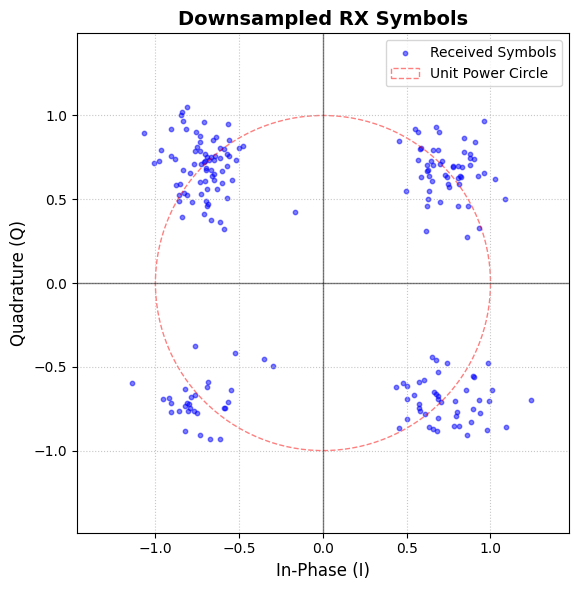

--- 測試完成 (耗時 0.2292 秒) ---
=> ✅ 測試通過：完美還原文字！(雜訊在容許範圍內，硬體判決成功)
[Output] 初始字元: Hello Satellite! This is a test message from Earth.
[Output] 接收字元: Hello Satellite! This is a test message from Earth.


In [88]:
config = SystemConfig()
testbench = EndToEndTestbench(config)
testbench.run_b2b_test()